**1. Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
%matplotlib inline

**2. Get the Data**

In [4]:
df = pd.read_csv('CC_GENERAL.csv')

**3. Data Cleaning**

In [5]:
df = df.drop('CUST_ID', axis=1)

print(df.isnull().sum())

df = df.fillna(df.mean())

print(df.isnull().sum().sum())

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64
0


**4. Exploratory Data Analysis**

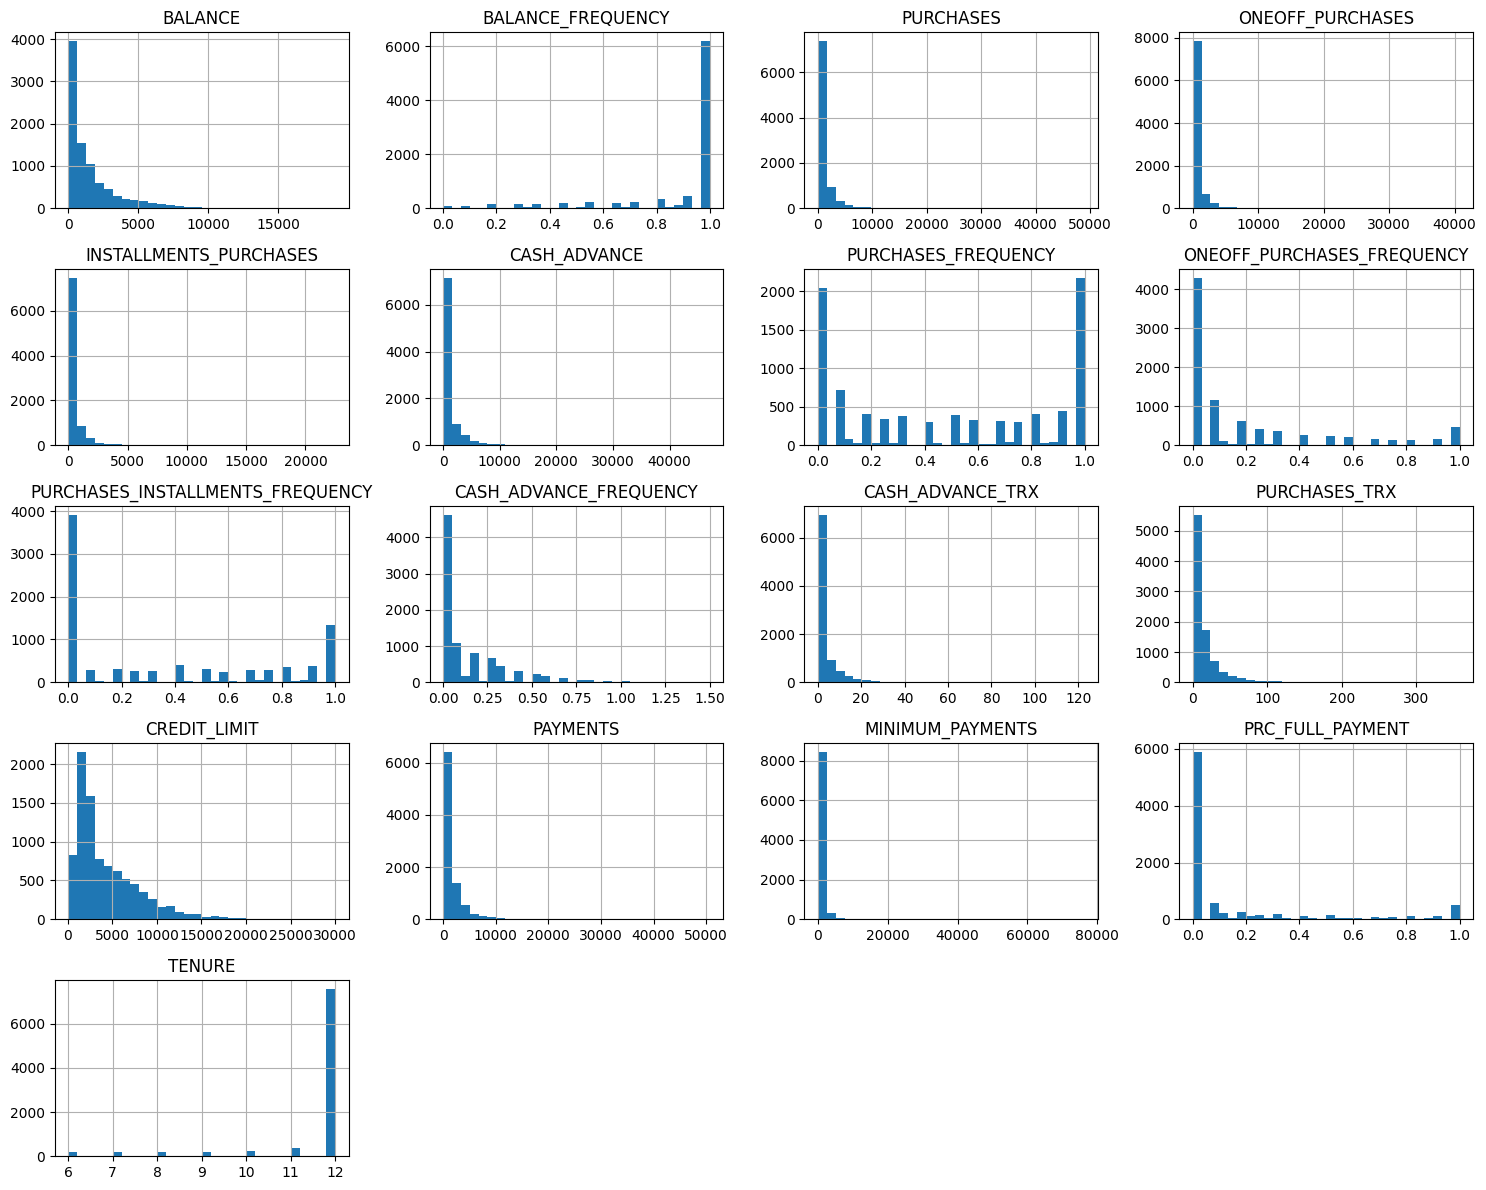

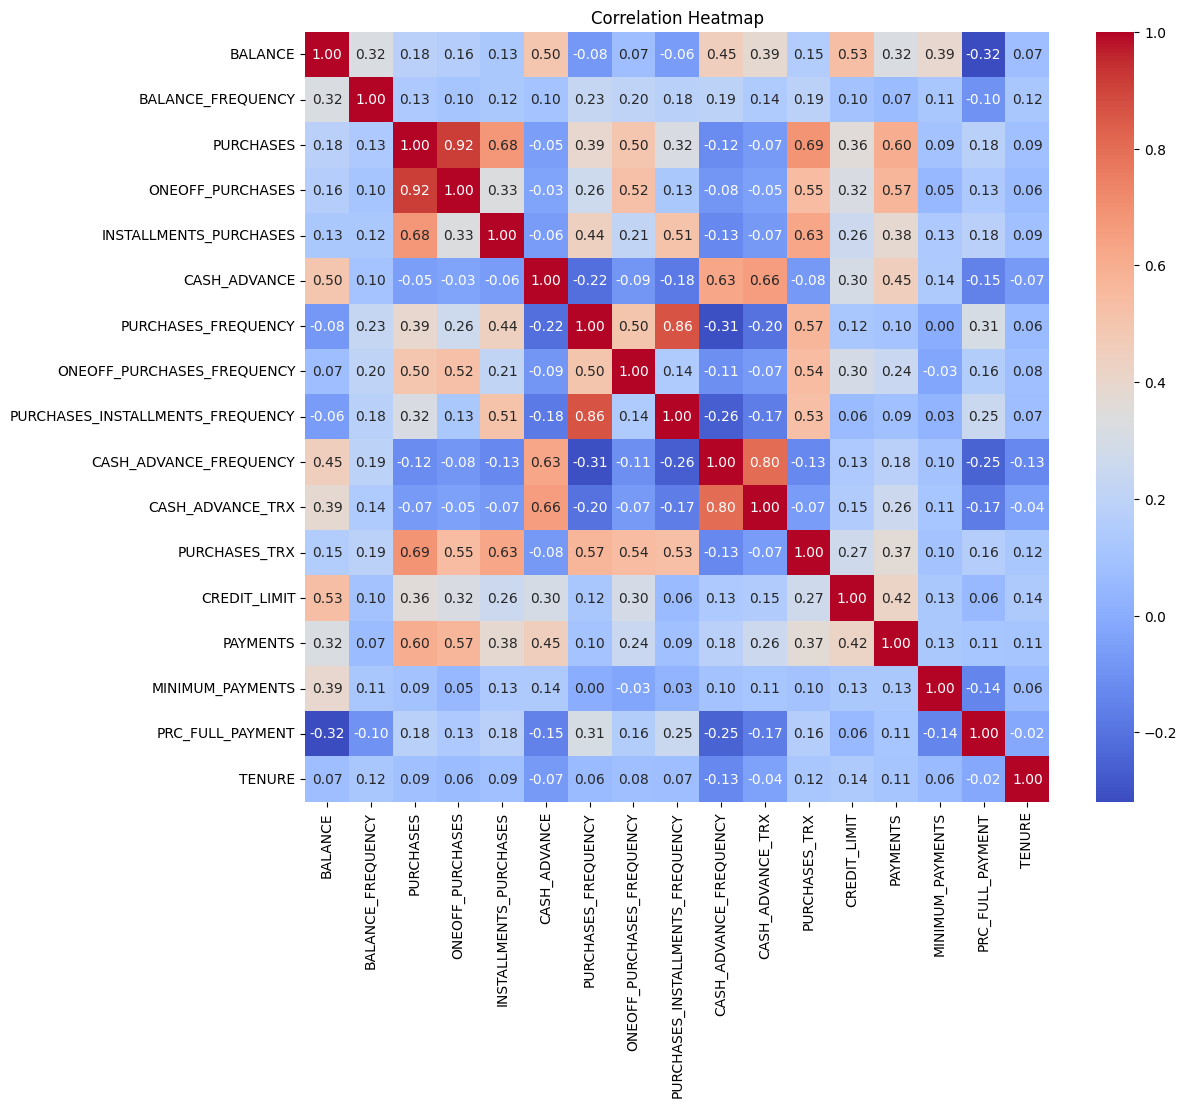

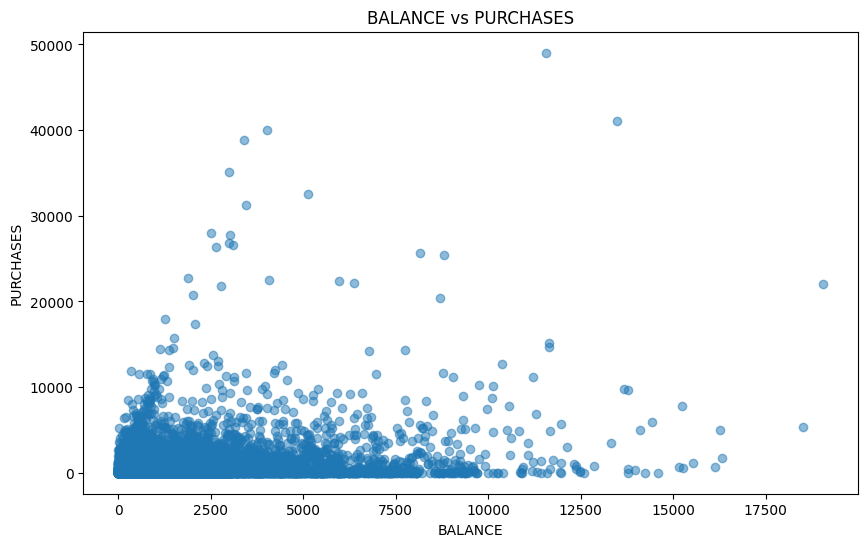

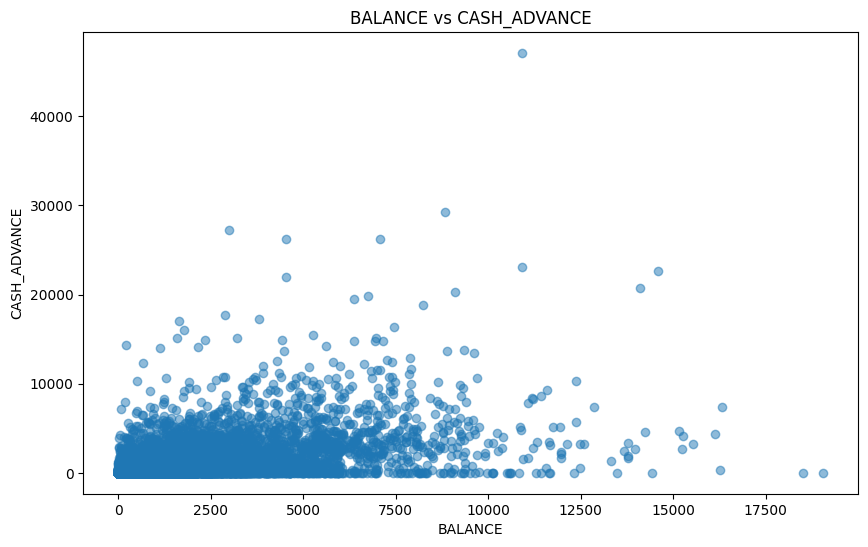

In [6]:
df.hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.5)
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.title('BALANCE vs PURCHASES')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'], alpha=0.5)
plt.xlabel('BALANCE')
plt.ylabel('CASH_ADVANCE')
plt.title('BALANCE vs CASH_ADVANCE')
plt.show()

**5. Feature Scaling**

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

**6. Elbow Method**

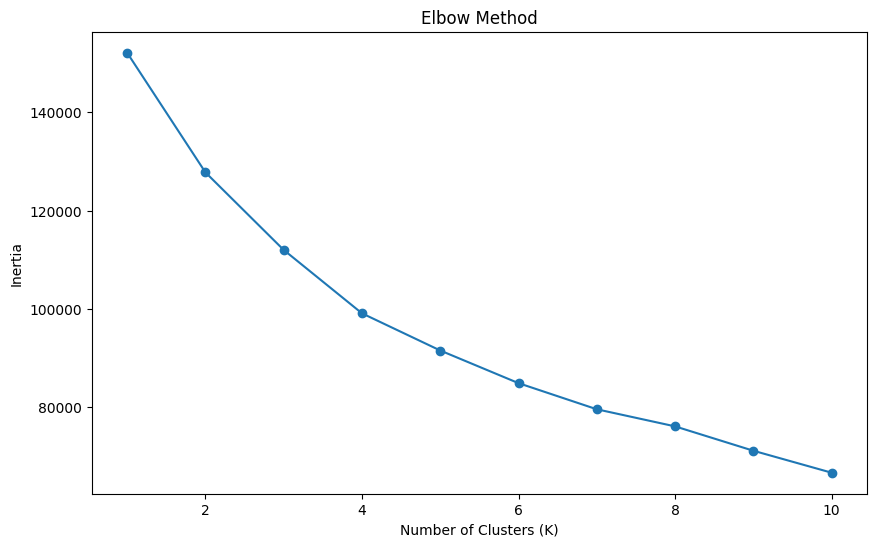

In [8]:
inertia_values = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

**7. Silhouette Score**

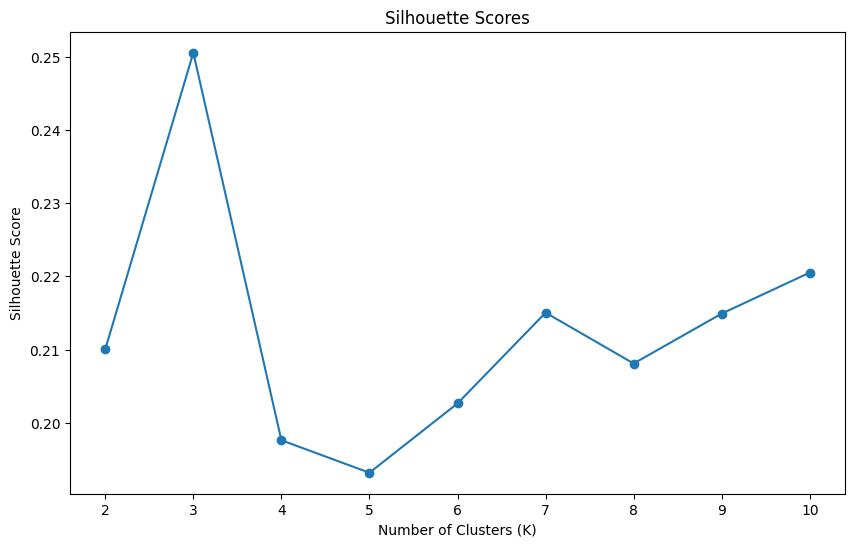

,K,Silhouette
0,2,0.210033
1,3,0.250556
2,4,0.197607
3,5,0.193169
4,6,0.202639
5,7,0.215038
6,8,0.208092
7,9,0.214912
8,10,0.220518


In [9]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

pd.DataFrame({'K': range(2,11), 'Silhouette': silhouette_scores})

**8. Final Model (K=4 chosen for balanced segmentation)**

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())

       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
3  1666.670542           0.636364    1499.00           1499.00   
4   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000                          0.000000   
2                

**9. Cluster Analysis**

In [11]:
summary = df.groupby('Cluster').mean().round(2)
print(summary)

print(df['Cluster'].value_counts())

         BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                            
0         894.91               0.93    1236.18            593.97   
1        3551.15               0.99    7681.62           5095.88   
2        4602.46               0.97     501.90            320.37   
3        1011.75               0.79     269.97            209.85   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                        642.48        210.57                 0.89   
1                       2587.21        653.64                 0.95   
2                        181.61       4520.72                 0.29   
3                         60.39        595.76                 0.17   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
0                       

**10. Visualization (PCA)**

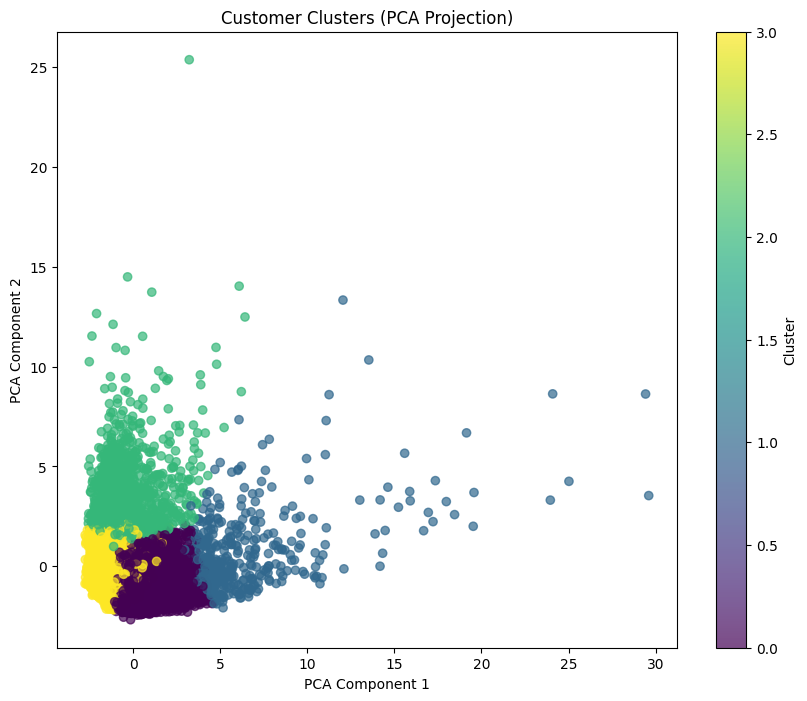

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Clusters (PCA Projection)')
plt.colorbar(label='Cluster')
plt.show()